# Steinhard Order Parameter 

To identify different ordered structures, there are many methods. We will look at one popular choice, Steinhard Bond Order Parameters (J. Chem. Phys. 129, 114707 (2008)). They are based on spherical harmonics. 

For a particle $i$, we calculate the average $q_l$ by summing the spherical harmonics between particle $i$ and its neighbors $j$ in a local region:

$ \overline{q}_{lm}(i) = \frac{1}{N_b} \sum \limits_{j=1}^{N_b}
Y_{lm}(\theta(\vec{r}_{ij}),\phi(\vec{r}_{ij})) $

This is then combined in a rotationally invariant fashion to remove local orientational order as follows:

$ q_l(i)=\sqrt{\frac{4\pi}{2l+1} \sum \limits_{m=-l}^{l} |\overline{q}_{lm}|^2 }  $

Then, to  compute the $\bar{q}_l$ averaged Steinhard bond order parameter, we perform a second
    averaging over the first neighbor shell of the particle to implicitly
    include information about the second neighbor shell. This averaging is
    performed by replacing the value $q_{lm}(i)$ in the original
    definition by $\bar{q}_{lm}(i)$, the average value of
    $q_{lm}(k)$ over all the $N_b$ neighbors $k$
    of particle $i$, including particle $i$ itself:

$ \overline{q}_{lm}(i) = \frac{1}{N_b} \sum \limits_{k=0}^{N_b}
        q_{lm}(k) $



In [2]:
import numpy as np 
import freud 
import glob
import gsd, gsd.hoomd
import matplotlib 
import matplotlib.pyplot as plt 

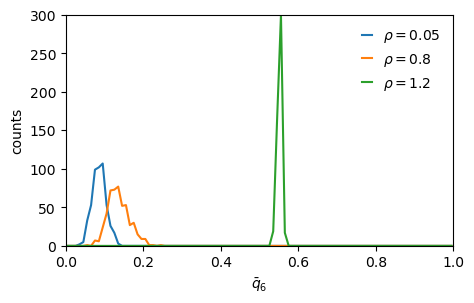

In [60]:
fig, ax = plt.subplots(figsize=(5,3))

files = ['../04-pair-correlation-function/gas/run_gas_0.05_1.00.gsd',
         '../04-pair-correlation-function/liquid/run_liquid_0.80_1.00.gsd',
         '../04-pair-correlation-function/fcc/run_fcc_1.20_1.00.gsd']
rho = ['0.05','0.8','1.2']
for i,file in enumerate(files): 
        
    trajectory = gsd.hoomd.open(file,mode='r') 
    
    points=trajectory[-1].particles.position
    box = trajectory[-1].configuration.box
    
    q6 = freud.order.Steinhardt(l=6,average=True)
    q6.compute(system=(box,points),neighbors={"num_neighbors": 12})
    q6 = q6.particle_order
    hist, edges = np.histogram(q6,range=[0,1],bins=100)
    centers = (edges[1:]+edges[:-1])/2
    ax.plot(centers, hist,label=r'$\rho=%s$'%rho[i])

ax.set_xlabel(r'$\bar{q}_6$')
ax.set_ylabel('counts')
ax.set_ylim([0,300])
ax.set_xlim([0,1])
ax.legend(frameon=False,loc='upper right',handlelength=0.7)
plt.show()

## Distinguishing Different Crystal Structures 

Using different values of $l$ can help distinguish different crystal structures by their symmetry and coordination number. We know that simple cubic has a coordination number of 6, BCC has 8, and FCC has 12, so we are scanning $\bar{q}_l$ for $l=4,6,8,12$:

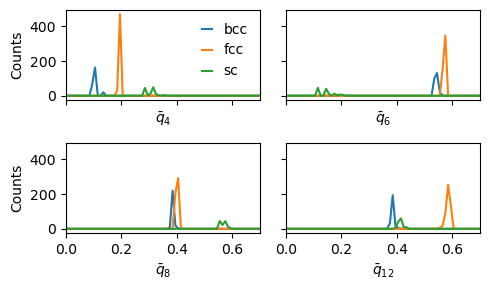

In [95]:
fig, ax = plt.subplots(2,2,figsize=(5,3),sharex=True,sharey=True)
ax  = ax.flatten() 

noise = 0.01
bcc = freud.data.UnitCell.bcc()
bcc_system = bcc.generate_system(5, sigma_noise=noise)

fcc = freud.data.UnitCell.fcc()
fcc_system = fcc.generate_system(5, sigma_noise=noise)

sc = freud.data.UnitCell.sc()
sc_system = sc.generate_system(5, sigma_noise=noise)

q_bcc = []
q_fcc = [] 
q_sc = [] 

for i,l in enumerate([4,6,8,12]):
    ql = freud.order.Steinhardt(l)

    ql.compute(bcc_system, neighbors={"num_neighbors": 12})
    ql_bcc = ql.particle_order
    q_bcc.append(ql_bcc) 
    
    hist, edges = np.histogram(ql_bcc,range=[0,1],bins=100)
    centers = (edges[1:]+edges[:-1])/2
    ax[i].plot(centers, hist)
    
    ql.compute(fcc_system, neighbors={"num_neighbors": 12})
    ql_fcc = ql.particle_order
    q_fcc.append(ql_fcc) 
    
    hist, edges = np.histogram(ql_fcc,range=[0,1],bins=100)
    ax[i].plot(centers, hist)
    
    ql.compute(sc_system, neighbors={"num_neighbors": 12})
    ql_sc = ql.particle_order
    q_sc.append(ql_sc)
    
    hist, edges = np.histogram(ql_sc,range=[0,1],bins=100)
    ax[i].plot(centers, hist)

    ax[i].set_xlabel(r'$\bar{q}_{%d}$'%l)

ax[0].set_xlim([0,0.7])
ax[0].set_ylabel('Counts')
ax[2].set_ylabel('Counts')

handles, labels = ax[0].get_legend_handles_labels()
manual_line = matplotlib.lines.Line2D([0], [0],c='tab:blue')
handles.append(manual_line)
labels.append('bcc')
manual_line = matplotlib.lines.Line2D([0], [0],c='tab:orange')
handles.append(manual_line)
labels.append('fcc')
manual_line = matplotlib.lines.Line2D([0], [0],c='tab:green')
handles.append(manual_line)
labels.append('sc')
ax[0].legend(handles, labels,frameon=False, handlelength=0.7)

fig.tight_layout()

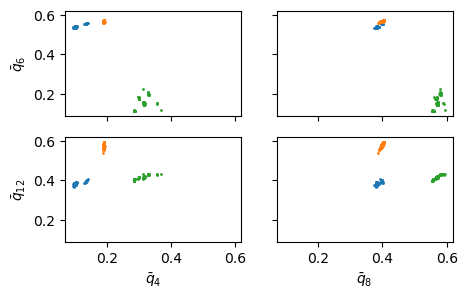

In [113]:
fig, ax = plt.subplots(2,2,figsize=(5,3),sharex=True,sharey=True)
ax  = ax.flatten()  

ax[0].scatter(q_bcc[0],q_bcc[1],s=1)
ax[0].scatter(q_fcc[0],q_fcc[1],s=1)
ax[0].scatter(q_sc[0],q_sc[1],s=1)
#ax[0].set_xlabel('q_4')
ax[0].set_ylabel(r'$\bar{q}_6$')

ax[1].scatter(q_bcc[2],q_bcc[1],s=1)
ax[1].scatter(q_fcc[2],q_fcc[1],s=1)
ax[1].scatter(q_sc[2],q_sc[1],s=1)
#ax[1].set_xlabel('q_8')
#ax[1].set_ylabel('q_6')

ax[2].scatter(q_bcc[0],q_bcc[3],s=1)
ax[2].scatter(q_fcc[0],q_fcc[3],s=1)
ax[2].scatter(q_sc[0],q_sc[3],s=1)
ax[2].set_xlabel(r'$\bar{q}_4$')
ax[2].set_ylabel(r'$\bar{q}_{12}$')

ax[3].scatter(q_bcc[2],q_bcc[3],s=1)
ax[3].scatter(q_fcc[2],q_fcc[3],s=1)
ax[3].scatter(q_sc[2],q_sc[3],s=1)
ax[3].set_xlabel(r'$\bar{q}_8$')
#ax[3].set_ylabel('q_12')

plt.show()

## Other Order Parameters 

- Common Neighbor Analysis (CNA) [Honeycutt and Andersen, J. Phys. Chem. 91, 4950]. The CNA is an algorithm to compute a fingerprint for pairs of atoms, which is designed to characterize the local structural environment. Typically, the CNA is used as an effective filtering method to classify atoms in crystalline systems [Faken and Jonsson, Comput. Mater. Sci. 2, 279], with the goal to get a precise understanding of which atoms are associated with which phases, and which are associated with defects. There are variants with fixed or adaptive cutoffs.
- Polyhedral Template Matching (PTM) [Larsen,Modelling Simul. Mater. Sci. Eng. 24, 055007 (2016)] classifies the local structural environment of particles using PTM method, which allows identification of the local crystalline structure of simple condensed phases. The templates use a mixture of nearest neighbors, and neighbors of neighbors.
- Identifying common crystalline and other structures based on an analysis of the distribution of angles formed by the pairs of neighbors of a central atom. The method is known as Ackland-Jones bond-angle method [Ackland and Jones, Phys. Rev. B 73, 054104]. The algorithm assigns a structural type to each particle having a local environment that matches one of the known structures (FCC, BCC, HCP, icosahedral).
- Centrosymmetry parameter (CSP) [Kelchner, Plimpton, Hamilton, Phys. Rev. B, 58, 11085 (1998)] for each particle. In solid-state systems the centrosymmetry parameter is a useful measure of the local lattice disorder around an atom and can be used to characterize whether the atom is part of a perfect lattice, a local defect (e.g. a dislocation or stacking fault), or located at a surface.
- many more, including Machine Learning based ones
  
